# 3栋1-4单元 + 4栋2单元 喂食数据分析

## README

## 1 数据预处理

In [ ]:
# import re
# import pandas as pd
# from dataclasses import dataclass
from meta.feed_file_meta import FeedFileMeta
from pathlib import Path

import pandas as pd
file_name = '育肥3-1单元饲喂记录-2025-08-28--2025-12-10'

# 标准字段名称 中-英


# 转舍前日龄
INIT_age = 32 

# 原始食量数据路径
PATH_FEED_ori = Path('data/feed_record_ori')
PATH_FEED_processed = Path('data/feed_record_processed')

# 读取需要的数据
## ? 目前没有做时间插值

def get_feed_data(file_name:str):
    """
    读取并清洗生猪饲喂记录数据，生成栏级（column）与单元级（build）两种时间序列数据。

    本函数从指定 Excel 文件中读取原始饲喂记录，对字段进行标准化、
    去重与排序，并基于饲喂日期计算猪只日龄（age）。
    最终返回不同统计粒度的数据表。

    Parameters
    -----------------
    file_name : str
        饲喂记录 Excel 文件名（不含扩展名）。
        文件路径默认为 ``data/feed_record_ori/{file_name}.xlsx``。
        文件名需符合 ``FeedFileMeta`` 的解析规则（例如包含单元号和日期范围）。
    granularity : {'column', 'build', None}, optional
        返回数据的统计粒度：
        - None（默认）：同时返回栏级数据和单元级数据
        - 'column'：仅返回栏级饲喂数据
        - 'build'：仅返回单元级饲喂数据
    
    Returns
    -------
    df_col : pandas.DataFrame
        栏级饲喂数据，包含以下字段：
        - Date : datetime.date，饲喂日期（已转换为 date 对象）。
        - col_num : int / str，栏号。
        - food_col_kg : float，单栏喂料量。
        - age : int，对应日龄。

    df_build : pandas.DataFrame
        单元级饲喂数据，包含以下字段：
        - Date : datetime.date，饲喂日期（已转换为 date 对象）。
        - food_total_kg : float，当日单元总采食量。
        - age : int，对应日龄。

    meta : FeedFileMeta
        包含文件解析元数据的对象，包含以下主要属性：
        - stage : str，阶段（如“育肥”）。
        - unit : str，单元号。
        - start_date : datetime.date，记录开始日期。
        - end_date : datetime.date，记录结束日期。

    Notes
    -----
    - 日龄（age）计算方式为：
      ``age = (Date - start_date).days``
      注意：此计算未包含全局的 ``INIT_age``（转舍前日龄），仅计算文件记录范围内的相对天数。
    - 函数内部会对数据进行去重和排序处理，确保日期和栏号的有序性。
    - 本函数默认假定 Excel 表头位于第 4 行（index=3）。
    - 插值或缺失值处理需在函数外单独完成。
    """

    # 读取原始数据
    meta = FeedFileMeta(file_name)      # 获取单元号、起止日期、总计时长
    # print(file_name)
    print(f'当前文件信息：{meta.to_dict()}')

    df = (pd.read_excel(f'data/feed_record_ori/{file_name}.xlsx', index_col=False, header=3)
        .loc[:, ['饲喂日期', '栏号', '单栏喂料量(Kg)', '每日采食总量(Kg)']]   # 选取指定列 
        .rename(columns=STD_header_name)                            # 英文列名变更
        .sort_values(by=['Date', 'col_num'])                        # 日期、栏升序
        .drop_duplicates()                                          # 删除重复行
        .assign(Date=lambda x: pd.to_datetime(x["Date"]).dt.date)   # 转为时间格式
        .reset_index(drop=True)                                     # 重设索引
        )
    
    start_date, end_date = meta.start_date, meta.end_date    # 获取文件时间段
    df['age'] = [(d - start_date).days for d in df['Date']] # 计算总日龄（未纠准）

    # 获取栏精度数据
    df_col = df[["Date", "col_num", "food_col_kg", "age"]].drop_duplicates() 

    # 获取单元精度数据
    df_build = df[["Date", "food_total_kg", "age"]].drop_duplicates()

    return df_col, df_build, meta  # 返回 unit 名称
    
df_col, df_build, meta = get_feed_data(file_name)

当前文件信息：{'stage': '育肥', 'unit': '3-1', 'start_date': datetime.date(2025, 8, 28), 'end_date': datetime.date(2025, 12, 10), 'duration_days': 105}


In [ ]:
def save_incremental_parquet(df: pd.DataFrame, granularity: str, meta: FeedFileMeta):
    """
    增量写入 parquet 文件：
    - 如果 parquet 存在，则读取原始数据，合并去重后再保存
    - 如果 parquet 不存在，则直接保存
    """
    file_path = PATH_feed_processed / f"{meta.stage}{meta.unit}_{granularity}.parquet"
    
    if file_path.exists():
        # 读取已有 parquet
        df_existing = pd.read_parquet(file_path, engine='pyarrow')
        # 合并并去重重排列
        df = pd.concat([df_existing, df], ignore_index=True).drop_duplicates()
        df['Date'] = pd.to_datetime(df['Date']).dt.date
        df = df.sort_values(by='Date')

    # 写入 parquet
    df.to_parquet(file_path, engine='pyarrow', index=False)


In [ ]:
from pathlib import Path
from glob import glob
# 批量处理所有excel
from pathlib import Path
from glob import glob

PATH_FEED_ORI = Path('data/feed_record_ori')

def process_all_excel(file_path):
    """
    批量处理指定目录下的所有 Excel 饲喂记录文件，并将其转换为 Parquet 格式保存。

    该函数会遍历指定目录下所有的 .xlsx 文件，对每个文件执行以下操作：
    1. 读取并清洗 Excel 数据（调用 `get_feed_data`）。
    2. 将处理后的栏级数据（column）和单元级数据（build）分别以增量方式保存为 Parquet 文件（调用 `save_incremental_parquet`）。

    Parameters
    ----------
    file_path : Path
        包含待处理 Excel 文件的目录路径。
        该目录下应包含符合命名规范的 .xlsx 文件（例如：'育肥3-1单元饲喂记录-2025-08-28--2025-12-10.xlsx'）。

    Notes
    -----
    - 依赖函数：
      - `get_feed_data`: 用于读取和解析 Excel 文件，返回 DataFrame 和元数据。
      - `save_incremental_parquet`: 用于将 DataFrame 增量写入 Parquet 文件。
    - 输出路径：
      - Parquet 文件将保存至全局变量 `PATH_feed_processed` 指定的目录（需在调用前定义）。
      - 输出文件命名格式为 `{meta.stage}{meta.unit}_{granularity}.parquet`。
    - 处理逻辑：
      - 函数会捕获目录下所有后缀为 .xlsx 的文件。
      - 处理过程中会打印当前正在处理的文件名及元数据信息（由 `get_feed_data` 内部实现）。

    """
    excel_files = list(file_path.glob('*.xlsx'))            # 全部路径
    file_names = [s.stem for s in excel_files]              # 文件名称
    for filename in file_names:
        df_col, df_build, meta = get_feed_data(filename)
        save_incremental_parquet(df_col, granularity='column', meta=meta)
        save_incremental_parquet(df_build, granularity='build', meta=meta)

process_all_excel(file_path=PATH_FEED_ORI)

当前文件信息：{'stage': '育肥', 'unit': '3-1', 'start_date': datetime.date(2025, 8, 28), 'end_date': datetime.date(2025, 12, 10), 'duration_days': 105}
当前文件信息：{'stage': '育肥', 'unit': '3-1', 'start_date': datetime.date(2025, 12, 1), 'end_date': datetime.date(2026, 1, 12), 'duration_days': 43}
当前文件信息：{'stage': '育肥', 'unit': '3-2', 'start_date': datetime.date(2025, 8, 28), 'end_date': datetime.date(2025, 12, 10), 'duration_days': 105}
当前文件信息：{'stage': '育肥', 'unit': '3-2', 'start_date': datetime.date(2025, 12, 1), 'end_date': datetime.date(2026, 1, 12), 'duration_days': 43}
当前文件信息：{'stage': '育肥', 'unit': '3-3', 'start_date': datetime.date(2025, 8, 28), 'end_date': datetime.date(2025, 12, 10), 'duration_days': 105}
当前文件信息：{'stage': '育肥', 'unit': '3-3', 'start_date': datetime.date(2025, 12, 1), 'end_date': datetime.date(2026, 1, 12), 'duration_days': 43}
当前文件信息：{'stage': '育肥', 'unit': '3-4', 'start_date': datetime.date(2025, 8, 28), 'end_date': datetime.date(2025, 12, 10), 'duration_days': 105}
当前文件信

In [ ]:
import pandas as pd
from pathlib import Path

def update_age(
    file_path: Path, 
    reference_date: pd.Timestamp, 
    reference_age: int,
    date_column: str = 'Date'
):
    """
    根据指定参考日期和参考日龄，重新计算整个 parquet 文件的 age。
    
    Parameters
    ----------
    file_path : Path
        parquet 文件路径
    reference_date : pd.Timestamp
        参考日期（例如 2025-12-01）
    reference_age : int
        参考日期对应的日龄
    date_column : str, default 'Date'
        parquet 中日期列名
    """
    if not file_path.exists():
        print(f"{file_path} 不存在")
        return
    
    df = pd.read_parquet(file_path, engine='pyarrow')
    
    # 转 datetime
    df[date_column] = pd.to_datetime(df[date_column])
    
    # 计算 age
    df['age'] = [(d - reference_date).days + reference_age for d in df[date_column]]
    
    # 保存 parquet
    df.to_parquet(file_path, engine='pyarrow', index=False)
    print(f"更新 {file_path} 的日龄 | 总行数: {len(df)}")


In [ ]:
update_age(PATH_feed_processed / '育肥3-1_build.parquet', reference_date=pd.Timestamp('2025-08-28'), reference_age=35)
update_age(PATH_feed_processed / '育肥3-2_build.parquet', reference_date=pd.Timestamp('2025-08-21'), reference_age=32)
update_age(PATH_feed_processed / '育肥3-3_build.parquet', reference_date=pd.Timestamp('2025-08-21'), reference_age=32)
update_age(PATH_feed_processed / '育肥3-4_build.parquet', reference_date=pd.Timestamp('2025-08-21'), reference_age=32)

更新 data\feed_record_processed\育肥3-1_build.parquet 的日龄 | 总行数: 280
更新 data\feed_record_processed\育肥3-2_build.parquet 的日龄 | 总行数: 280
更新 data\feed_record_processed\育肥3-3_build.parquet 的日龄 | 总行数: 280
更新 data\feed_record_processed\育肥3-4_build.parquet 的日龄 | 总行数: 280


In [ ]:
file_name = '育肥3-1单元饲喂记录-2025-08-28--2025-12-10'

In [ ]:
df = pd.read_parquet(PATH_feed_processed / '育肥3-1_build.parquet', engine='pyarrow')

In [ ]:
df

,Date,food_total_kg,age
0,2025-08-28,119.2,35
1,2025-08-28,119.2,35
2,2025-08-29,189.6,36
3,2025-08-29,189.6,36
4,2025-08-30,233.6,37
...,...,...,...
275,2026-01-09,0.0,169
276,2026-01-10,0.0,170
277,2026-01-10,0.0,170
278,2026-01-11,0.0,171


## 1 各单元总量变化曲线

In [ ]:
from src.config.path import PATH_FEED_PROCESSED
import pandas as pd

df_31_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-1_column.parquet', engine='pyarrow').drop_duplicates()
df_32_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-2_column.parquet', engine='pyarrow').drop_duplicates()
df_33_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-3_column.parquet', engine='pyarrow').drop_duplicates()
df_34_col = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-4_column.parquet', engine='pyarrow').drop_duplicates()

df_31_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-1_build.parquet', engine='pyarrow').drop_duplicates()
df_32_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-2_build.parquet', engine='pyarrow').drop_duplicates()
df_33_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-3_build.parquet', engine='pyarrow').drop_duplicates()
df_34_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-4_build.parquet', engine='pyarrow').drop_duplicates()

### 1.1 单元时序绘制

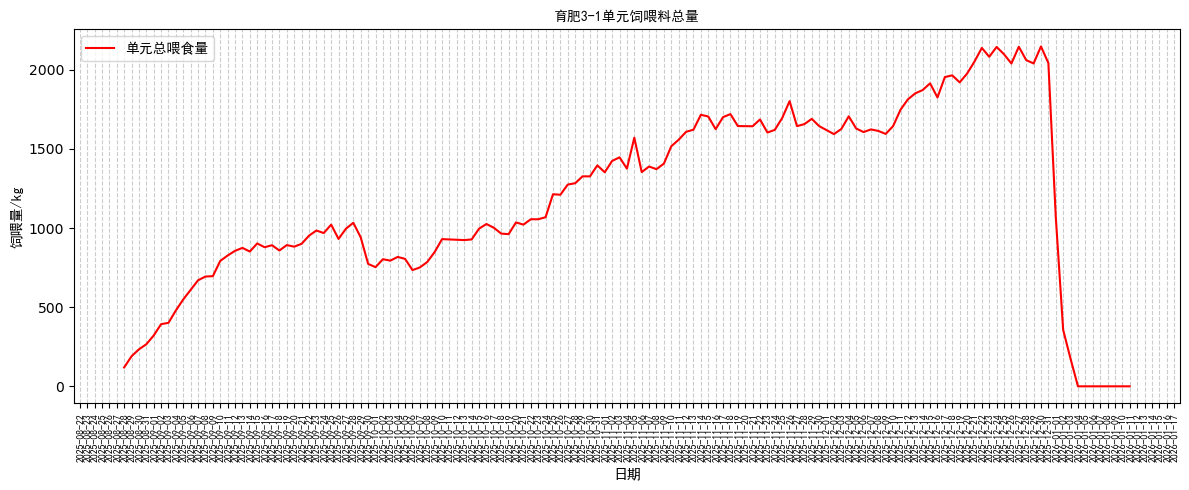

In [ ]:
from src.visualization.line_plot import line_static_feed_build
line_static_feed_build(df_31_build, unit="育肥3-1单元")

### 1.2 单元总量时序对比

读取四个Excel，绘制不同单元的单元总量变化趋势，四条线对比，交互曲线

In [ ]:
from src.visualization.line_plot import line_dynamic_feed_build

line_dynamic_feed_build([df_31_build, df_32_build, df_33_build, df_34_build], name_list=["育肥3-1单元", "育肥3-2单元", "育肥3-3单元", "育肥3-4单元"])

### 1.3 三栋各单元猪群期望重量

In [ ]:
# 数据处理
import pandas as pd
df = pd.read_excel('data/三栋1-4单元总量统计.xlsx')  # 保存备用

FCR = 2.65

# 计算各单元推测重量
for i in range(4):
    col_name = df.columns[i+1]
    df_temp = df.copy()
    df_temp['累计总量'] = df[col_name].cumsum()  # 累计采食量
    df[f'{col_name}推测重量'] = (df_temp['累计总量'] / FCR)

# 计算单元均值推测重量
df['均值累计总量'] = df['单元均值'].cumsum()
df['均值推测重量'] = (df['均值累计总量'] / FCR)  # 初始体重30kg

# df.to_excel('data/三栋1-4单元推测重量统计.xlsx')  # 保存备用

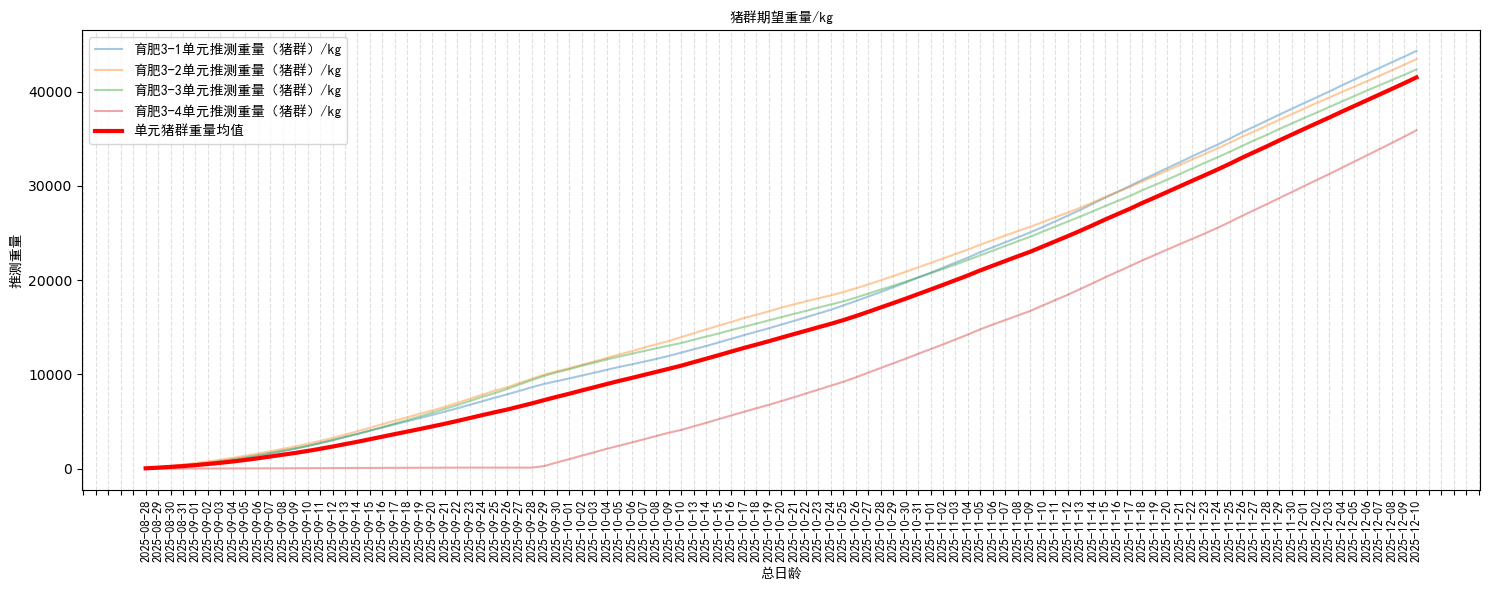

In [ ]:
# 可视化
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,6))
for i in range(4):
    col_name = f'育肥3-{i+1}单元推测重量'
    plt.plot(df['饲喂日期'], df[col_name], label=f'{col_name}（猪群）/kg', alpha=0.4)
plt.plot(df['饲喂日期'], df['均值推测重量'], color='red', label='单元猪群重量均值', linewidth=3)
ax = plt.gca()
# x 轴刻度间隔 = 1
ax.xaxis.set_major_locator(MultipleLocator(1))
# 添加 x 轴虚线（竖向网格线）
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.xlabel('总日龄', fontproperties=CN_font)
plt.ylabel('推测重量', fontproperties=CN_font)
plt.title("猪群期望重量/kg", fontproperties=CN_font)

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=9)
plt.legend(prop=CN_font)
plt.tight_layout()
plt.savefig('figure/3栋各单元猪群期望重量(kg).png', dpi=300)
plt.show()

### 1.4 三栋vs四栋2单元单猪生长曲线对比

In [ ]:
# 数据处理
import pandas as pd

df_build3 = pd.read_excel('data/三栋1-4单元推测重量统计.xlsx', index_col=False)
df_build4 = pd.read_excel('data/四栋2单元推测重量统计.xlsx', index_col=False)

df_build3_n = pd.read_excel('data/三栋总存栏数据.xlsx').dropna(axis=1, how='all').rename(columns={'日期': '饲喂日期'})
df_build3_n['饲喂日期'] = pd.to_datetime(df_build3_n['饲喂日期'])

df_build3['饲喂日期'] = pd.to_datetime(df_build3['饲喂日期'])
df_build4['饲喂日期'] = pd.to_datetime(df_build4['饲喂日期'])

df_build3['总日龄'] = (df_build3['饲喂日期'] - pd.to_datetime('2025-08-28')).dt.days + 32

# 计算3单元只猪均
df_build3 = df_build3.merge(df_build3_n, on='饲喂日期')
df_build3['实际推测重量'] = df_build3['均值推测重量'] * 4 / df_build3['存栏'] + 14

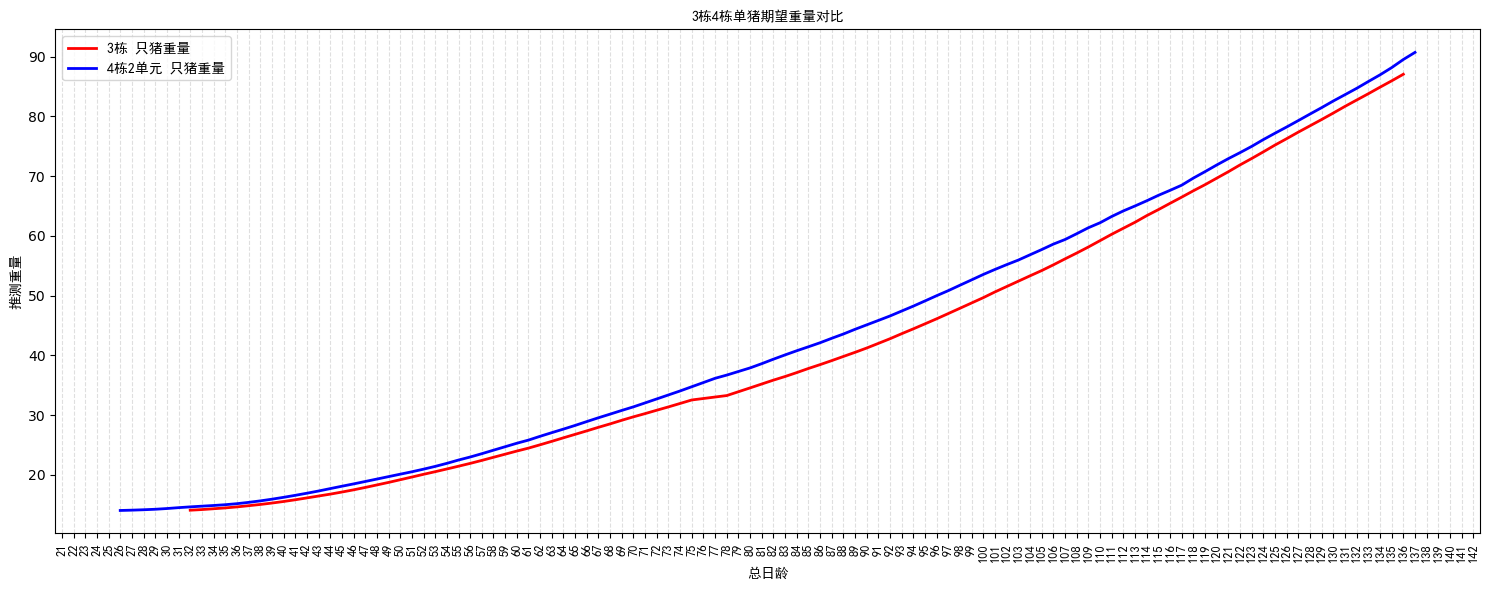

In [ ]:
# 可视化
import matplotlib.pyplot as plt
from matplotlib import font_manager
# import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,6))
plt.plot(df_build3['总日龄'], df_build3['实际推测重量'], color='red', label='3栋 只猪重量', linewidth=2)
plt.plot(df_build4['总日龄'], df_build4['实际推测重量'], color='blue', label='4栋2单元 只猪重量', linewidth=2)


ax = plt.gca()
# x 轴刻度间隔 = 1
ax.xaxis.set_major_locator(MultipleLocator(1))

# 添加 x 轴虚线（竖向网格线）
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.xlabel('总日龄', fontproperties=CN_font)
plt.ylabel('推测重量', fontproperties=CN_font)
plt.title("3栋4栋单猪期望重量对比", fontproperties=CN_font)

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=9)
plt.legend(prop=CN_font)
plt.tight_layout()
plt.savefig('figure/3栋4栋单猪期望重量对比(kg).png', dpi=300)
plt.show()


## 2 单栏数据分析

### 2.1 单元单栏变化率热力图

#### 定义数据处理与可视化函数

In [ ]:
# 配置数据
# 全局数据处理配置
SMOOTH_WIN = 1  # 平滑窗口大小
LAG = 1         # 滞后阶数

# 全局绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

# 事件绘图参数配置
color_map_event = {
    '发热': 'red',
    '神经症状': 'green',
    '咳嗽': 'blue',
    '拉稀': 'orange',  
}

# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# 1. 处理食料数据
def process_food_data(file_name, sheet_name, if_partial=False, start_date=None, end_date=None):
    # 数据读取与平滑
    # Food data
    df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
    # df['Date'] = pd.to_datetime(df['Date'])

    # 如果只处理部分数据
    if if_partial:
        df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

    # 构造平滑序列
    df_for_smooth = df.drop(columns=['Date']).replace(0, np.nan)   # 保证NaN不参与平滑计算，临时表格

    df_smooth = (
        df_for_smooth.rolling(window=SMOOTH_WIN, center=True, min_periods=1).mean()
    )
    df_smooth[df == 0] = 0  # 回填0

    # 构造滞后序列
    df_smooth_lag = df_smooth.shift(LAG)

    # 计算滞后变化率
    df_pct_change = (df_smooth - df_smooth_lag) / df_smooth_lag * 100 # 转为百分比
    df_pct_change.index = df['Date']    # 添加日期
    df_pct_change = df_pct_change[LAG:]   # 剔除空行

    # 转标准数字，保证顺利绘图
    df_num = df_pct_change.apply(pd.to_numeric, errors='coerce')
    df_num = df_num.fillna(float('inf'))
    df_num.index = df_pct_change.index

    df_num = df_num.T

    return df_num, df_pct_change

In [ ]:
# 2. 处理事件（治疗）数据
def process_event_data(read_file_name, sheet_name):
    
    df = pd.read_excel(f'data/event/{read_file_name}.xlsx', sheet_name=sheet_name, index_col=False)[['治疗日期', '数量', '疾病名称']]
    # 只保留日期部分
    df['治疗日期'] = pd.to_datetime(df['治疗日期']).dt.date 

    # 合并同一天的事件
    df_event = df.groupby(['治疗日期', '疾病名称'], as_index=False)['数量'].sum()
    
    # df_event = df       # 用于绘制事件线
    df_event['治疗日期'] = pd.to_datetime(df_event['治疗日期']).dt.date

    event_dates = df_event['治疗日期']

    return df_event, event_dates

In [ ]:
# 3. 栏-变化率热力图
def plot_heatmap(df_num, df_event, plot_name, save_img=True):
    data = df_num.values

    # 1）绘制整体曲线
    plt.figure(figsize=(15, 6))
    im = plt.imshow(
        data,
        aspect='auto',      # 让时间轴拉伸
        cmap='coolwarm',
        origin='upper',      # 时间从上往下
        vmin = -100,
        vmax = 100,
        alpha=0.95,
    )

    plt.colorbar(im, label='Percentage(%)', shrink=0.9)
    plt.xlabel('时间', fontproperties = CN_font)
    plt.ylabel('栏号', fontproperties = CN_font)

    # 2）绘制事件垂直虚线
    ax = plt.gca()
    used_label = set()

    for date, group in df_event.groupby('治疗日期'):
        
        try:
            x_pos = df_num.columns.get_loc(pd.Timestamp(date))
        except KeyError:
            # 如果该日期不在绘图范围，直接跳过
            continue

        # 一天一条虚线
        ax.axvline(
            x=x_pos,
            linestyle='--',
            color='red',
            alpha=0.4,
            zorder=2
        )

        # 同一天多个 label
        for i, illness_type in enumerate(group['疾病名称']):
            color = color_map_event.get(illness_type, 'black')

            label = illness_type if illness_type not in used_label else None
            used_label.add(illness_type)

            ax.text(
                x_pos,
                1.01 + i * 0.02,   # 竖向错开
                illness_type,
                ha='center',
                va='bottom',
                transform=ax.get_xaxis_transform(),
                fontsize=6,
                color=color,
                fontproperties=CN_font
            )

    # 3）图显示调整
    # 显示真实刻度
    plt.xticks(
        ticks=np.arange(len(df_num.columns)),
        labels=df_num.columns,
        rotation=90, fontproperties=CN_font, fontsize=7)

    plt.yticks(
        ticks=np.arange(len(df_num.index)),
        labels=df_num.index,
        fontproperties=CN_font,
    )

    dates = pd.to_datetime(df_num.columns)
    step = 1  # 每 1 天显示一次
    tick_pos = np.arange(0, len(dates), step)

    plt.xticks(
        ticks=tick_pos,
        labels=dates[tick_pos].strftime('%Y-%m-%d'),
        rotation=90,
        fontproperties=CN_font,
        fontsize=7
    )

    plt.title(f'{plot_name}-T与T-{LAG}（win={SMOOTH_WIN} lag={LAG}）', fontproperties=CN_font, fontsize=12, pad=20)
    if save_img:
        plt.savefig(f'figure/{plot_name}-T与T-{LAG}（win={SMOOTH_WIN} lag={LAG}）.png', dpi=300, bbox_inches='tight')
    plt.show()

#### 育肥3-1单元

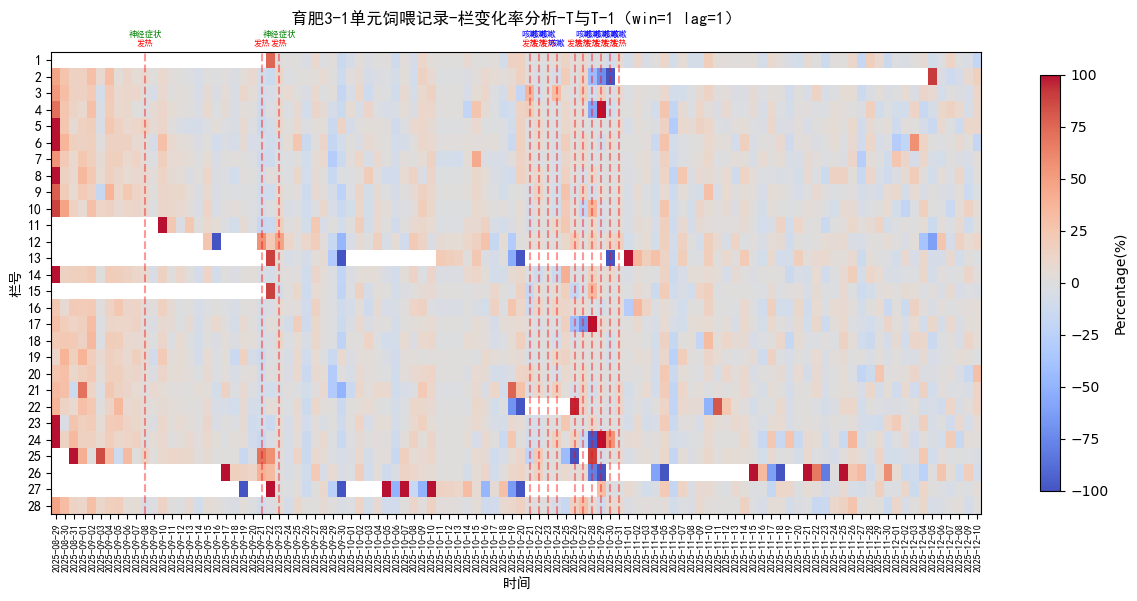

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-1单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_event, event_dates = process_event_data(read_file_name='治疗数据', sheet_name='03栋商品猪舍1单元')

plot_heatmap(df_num, df_event, '育肥3-1单元饲喂记录-栏变化率分析', save_img=True)

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-1单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_pct_plot= df_num.astype(float)

import plotly.express as px

fig = px.imshow(
    df_pct_plot,
    labels=dict(x="时间", y="栏数", color="料量变化百分比/%"),
    x=df_pct_plot.columns,           # 列名作为 x 轴
    y=df_pct_plot.index,             # 行索引作为 y 轴

    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,       # 0 对应中间颜色（白色）
    range_color=[-80, 80],

    # text_auto=True,
    aspect="auto",
    title="3栋1单元各栏饲料量变化率-%"

)

# 如果想让 y 轴从上到下显示（行1在最上面）
fig.update_yaxes(
    autorange="reversed",
    dtick = 1,
    showgrid=False,
    tickfont=dict(size=10)
)

# tickvals = list(range(0, len(df_pct_plot.columns), 3))   # 列索引位置
# ticktext = [df_pct_plot.columns[i].strftime("%Y-%m-%d") for i in tickvals]
fig.update_xaxes(
    # tickvals=tickvals,     # 指定刻度位置（列索引）
    # ticktext=ticktext,     # 指定显示文本
    tickformat="%Y-%m-%d",  # 年-月-日
    tickangle=-45,            # 可选：斜显示防止重叠
    tickfont=dict(size=10)
)

fig.write_html('figure/3栋1单元各栏饲料量变化率热力图.html', include_plotlyjs='cdn', full_html=True)
fig.show()

#### 育肥3-2单元

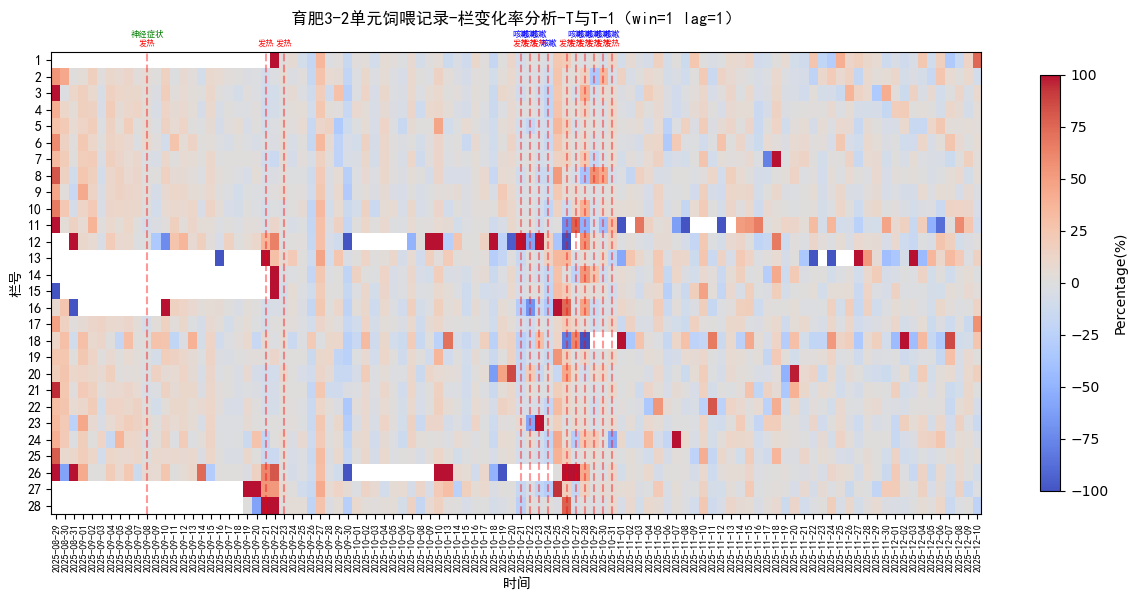

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-2单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_event, event_dates = process_event_data(read_file_name='治疗数据', sheet_name='03栋商品猪舍2单元')

plot_heatmap(df_num, df_event, '育肥3-2单元饲喂记录-栏变化率分析', save_img=True)

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-2单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_pct_plot= df_num.astype(float)

import plotly.express as px

fig = px.imshow(
    df_pct_plot,
    labels=dict(x="时间", y="栏数", color="料量变化百分比/%"),
    x=df_pct_plot.columns,           # 列名作为 x 轴
    y=df_pct_plot.index,             # 行索引作为 y 轴

    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,       # 0 对应中间颜色（白色）
    range_color=[-80, 80],

    # text_auto=True,
    aspect="auto",
    title="3栋2单元各栏饲料量变化率-%"

)

# 如果想让 y 轴从上到下显示（行1在最上面）
fig.update_yaxes(
    autorange="reversed",
    dtick = 1,
    showgrid=False,
    tickfont=dict(size=10)
)

# tickvals = list(range(0, len(df_pct_plot.columns), 3))   # 列索引位置
# ticktext = [df_pct_plot.columns[i].strftime("%Y-%m-%d") for i in tickvals]
fig.update_xaxes(
    # tickvals=tickvals,     # 指定刻度位置（列索引）
    # ticktext=ticktext,     # 指定显示文本
    tickformat="%Y-%m-%d",  # 年-月-日
    tickangle=-45,            # 可选：斜显示防止重叠
    tickfont=dict(size=10)
)

fig.write_html('figure/3栋2单元各栏饲料量变化率热力图.html', include_plotlyjs='cdn', full_html=True)
fig.show()

#### 育肥3-3单元

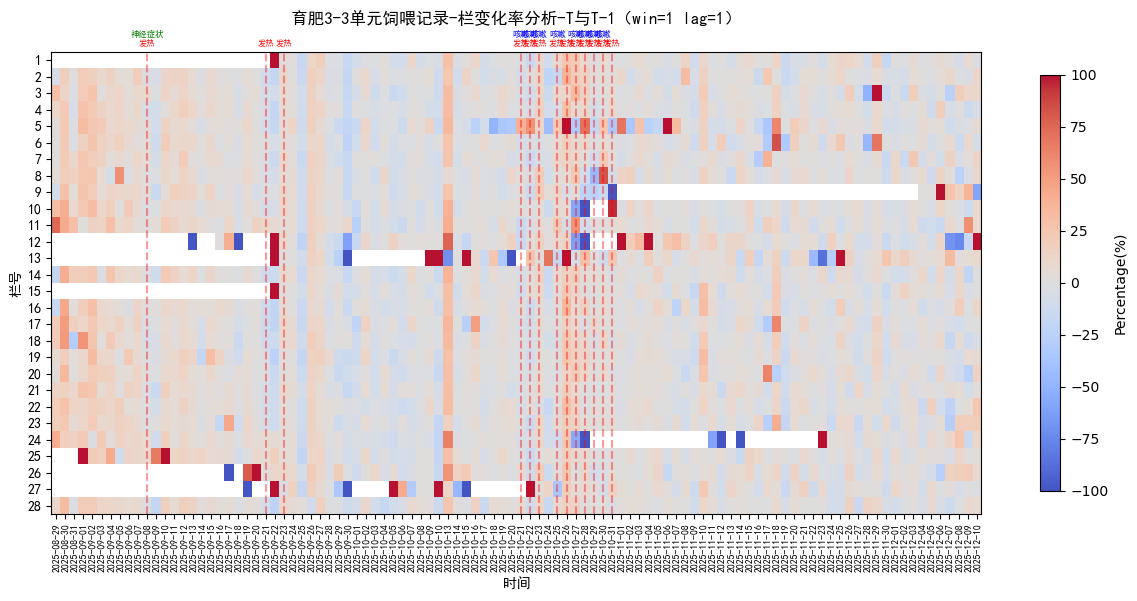

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-3单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_event, event_dates = process_event_data(read_file_name='治疗数据', sheet_name='03栋商品猪舍3单元')

plot_heatmap(df_num, df_event, '育肥3-3单元饲喂记录-栏变化率分析', save_img=True)

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-3单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_pct_plot= df_num.astype(float)

import plotly.express as px

fig = px.imshow(
    df_pct_plot,
    labels=dict(x="时间", y="栏数", color="料量变化百分比/%"),
    x=df_pct_plot.columns,           # 列名作为 x 轴
    y=df_pct_plot.index,             # 行索引作为 y 轴

    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,       # 0 对应中间颜色（白色）
    range_color=[-80, 80],

    # text_auto=True,
    aspect="auto",
    title="3栋3单元各栏饲料量变化率-%"

)

# 如果想让 y 轴从上到下显示（行1在最上面）
fig.update_yaxes(
    autorange="reversed",
    dtick = 1,
    showgrid=False,
    tickfont=dict(size=10)
)

# tickvals = list(range(0, len(df_pct_plot.columns), 3))   # 列索引位置
# ticktext = [df_pct_plot.columns[i].strftime("%Y-%m-%d") for i in tickvals]
fig.update_xaxes(
    # tickvals=tickvals,     # 指定刻度位置（列索引）
    # ticktext=ticktext,     # 指定显示文本
    tickformat="%Y-%m-%d",  # 年-月-日
    tickangle=-45,            # 可选：斜显示防止重叠
    tickfont=dict(size=10)
)

fig.write_html('figure/3栋3单元各栏饲料量变化率热力图.html', include_plotlyjs='cdn', full_html=True)
fig.show()

#### 育肥3-4单元

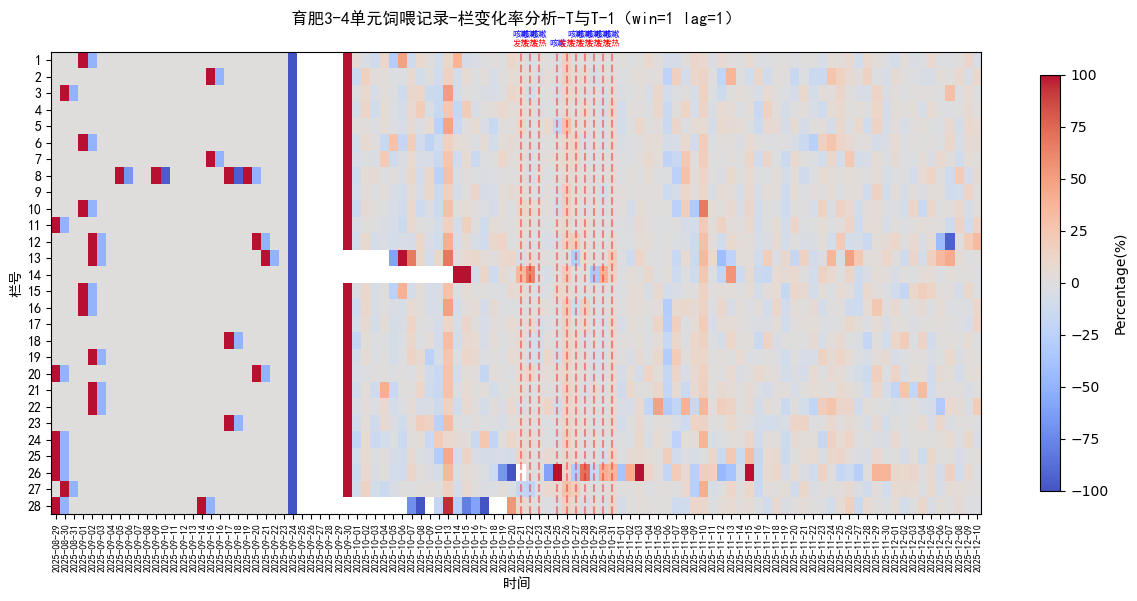

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_event, event_dates = process_event_data(read_file_name='治疗数据', sheet_name='03栋商品猪舍4单元')

plot_heatmap(df_num, df_event, '育肥3-4单元饲喂记录-栏变化率分析', save_img=True)

In [ ]:
df_num, df_pct_change = process_food_data('育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_pct_plot= df_num.astype(float)

import plotly.express as px

fig = px.imshow(
    df_pct_plot,
    labels=dict(x="时间", y="栏数", color="料量变化百分比/%"),
    x=df_pct_plot.columns,           # 列名作为 x 轴
    y=df_pct_plot.index,             # 行索引作为 y 轴

    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,       # 0 对应中间颜色（白色）
    range_color=[-80, 80],

    # text_auto=True,
    aspect="auto",
    title="3栋4单元各栏饲料量变化率-%"

)

# 如果想让 y 轴从上到下显示（行1在最上面）
fig.update_yaxes(
    autorange="reversed",
    dtick = 1,
    showgrid=False,
    tickfont=dict(size=10)
)

# tickvals = list(range(0, len(df_pct_plot.columns), 3))   # 列索引位置
# ticktext = [df_pct_plot.columns[i].strftime("%Y-%m-%d") for i in tickvals]
fig.update_xaxes(
    # tickvals=tickvals,     # 指定刻度位置（列索引）
    # ticktext=ticktext,     # 指定显示文本
    tickformat="%Y-%m-%d",  # 年-月-日
    tickangle=-45,            # 可选：斜显示防止重叠
    tickfont=dict(size=10)
)

fig.write_html('figure/3栋4单元各栏饲料量变化率热力图.html', include_plotlyjs='cdn', full_html=True)
fig.show()

#### 育肥4-2单元

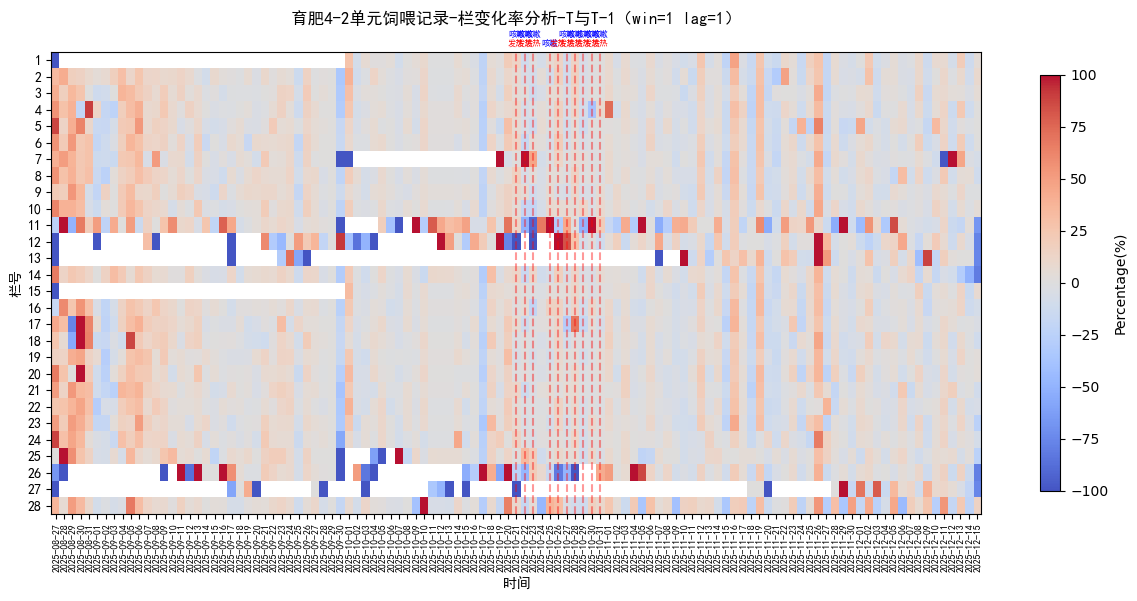

In [ ]:
df_num, df_pct_change = process_food_data('育肥4-2单元饲喂记录-2025-08-26--2025-12-16-单栏分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_event, event_dates = process_event_data(read_file_name='治疗数据', sheet_name='03栋商品猪舍4单元')

plot_heatmap(df_num, df_event, '育肥4-2单元饲喂记录-栏变化率分析', save_img=True)

In [ ]:
df_num, df_pct_change = process_food_data('育肥4-2单元饲喂记录-2025-08-25--2025-12-16-子表分析', '子表1-单栏喂料量', if_partial=False, start_date='2025-10-01', end_date='2025-12-31')
df_pct_plot= df_num.astype(float)

import plotly.express as px

fig = px.imshow(
    df_pct_plot,
    labels=dict(x="时间", y="栏数", color="料量变化百分比/%"),
    x=df_pct_plot.columns,           # 列名作为 x 轴
    y=df_pct_plot.index,             # 行索引作为 y 轴

    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,       # 0 对应中间颜色（白色）
    range_color=[-80, 80],

    # text_auto=True,
    aspect="auto",
    title="4栋2单元各栏饲料量变化率-%"

)

# 如果想让 y 轴从上到下显示（行1在最上面）
fig.update_yaxes(
    autorange="reversed",
    dtick = 1,
    showgrid=False,
    tickfont=dict(size=10)
)

# tickvals = list(range(0, len(df_pct_plot.columns), 3))   # 列索引位置
# ticktext = [df_pct_plot.columns[i].strftime("%Y-%m-%d") for i in tickvals]
fig.update_xaxes(
    # tickvals=tickvals,     # 指定刻度位置（列索引）
    # ticktext=ticktext,     # 指定显示文本
    tickformat="%Y-%m-%d",  # 年-月-日
    tickangle=-45,            # 可选：斜显示防止重叠
    tickfont=dict(size=10)
)

fig.write_html('figure/4栋2单元各栏饲料量变化率热力图.html', include_plotlyjs='cdn', full_html=True)
fig.show()

### 2.2 各单元单栏时序曲线

In [ ]:
from src.visualization.line_plot import line_dynamic_feed_column

line_dynamic_feed_column(df_31_col, '育肥3-1单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

In [ ]:
df_31_col

,Date,col_num,food_col_kg,age
0,2025-08-28,1,0.0,32
34,2025-08-28,2,6.0,32
13,2025-08-28,3,6.8,32
12,2025-08-28,4,5.6,32
28,2025-08-28,5,5.6,32
...,...,...,...,...
7805,2026-01-11,24,0.0,168
7806,2026-01-11,25,0.0,168
7795,2026-01-11,26,0.0,168
7807,2026-01-11,27,0.0,168


#### 绘图函数定义

In [ ]:
# 导入总体数据
import pandas as pd
df_total = pd.read_excel('data/三栋1-4单元总量统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)

# 全局绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

In [ ]:
import plotly.express as px
def plot_interactive_line_chart(file_name, sheet_name, col_name, if_partial=False, start_date=None, end_date=None, save_img=False):   
    df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'}).drop(columns=['Age'], errors='ignore')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.merge(df_total[col_name]/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={col_name: 'Total'}) # 单栏总值平均值
    # print(df)

    if if_partial:
        df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)

    # 为了 Plotly 交互，先把数据转成长格式
    df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')
    print(df_long)
    fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏喂料量变化曲线')
    fig.update_layout(
        autosize=True,       # 自动调整画布大小
        height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
        xaxis_title='日期',
        yaxis_title='料量/kg')

    # 突出'Total'列，增加一列 alpha 或者 color
    highlight_unit = 'Total'
    fig.update_traces(
        selector=lambda trace: trace.name == highlight_unit,
        line=dict(width=3, color='red'),    # 加粗
        marker=dict(size=8),                # 增大标记点
        opacity=1.0                         # 提高不透明度
    )

    # 设置余下列
    fig.update_traces(
        selector=lambda trace: trace.name != highlight_unit,
        line=dict(width=1),
        opacity=0.6
    )

    # 设置 x 轴按天显示，日期标签旋转 90 度
    fig.update_xaxes(
        dtick="D1",        # 每天一个刻度
        tickangle=-90,      # 标签旋转90度
        tickformat="%m-%d", # 可选：只显示月-日
        tickfont=dict(size=10)  # 调小字体，例如10号
    )

    fig.write_html(f'figure/{file_name}-单栏喂料量变化曲线.html', include_plotlyjs='cdn', full_html=True) if save_img else None
    fig.show()

#### 育肥3-1单元

In [ ]:
df_31_col

,Date,col_num,food_col_kg,age
0,2025-08-28,1,0.0,32
34,2025-08-28,2,6.0,32
13,2025-08-28,3,6.8,32
12,2025-08-28,4,5.6,32
28,2025-08-28,5,5.6,32
...,...,...,...,...
7805,2026-01-11,24,0.0,168
7806,2026-01-11,25,0.0,168
7795,2026-01-11,26,0.0,168
7807,2026-01-11,27,0.0,168


In [ ]:
df_31_col[['Date', 'col_num', 'food_col_kg']]
df_wide = df_31_col.pivot(index='Date', columns='col_num', values='food_col_kg')

In [ ]:
df_wide['Total'] = df_wide.mean(axis=1)

In [ ]:
df_wide

col_num,1,2,3,4,5,6,7,8,9,10,...,20,21,22,23,24,25,26,27,28,Total
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-28,0.0,6.0,6.8,5.6,5.6,4.8,7.2,3.2,5.6,3.6,...,7.6,7.2,6.4,4.0,3.6,0.0,0.0,0.0,6.0,4.257143
2025-08-29,0.0,8.8,10.4,9.6,11.2,10.0,11.2,8.4,10.0,6.8,...,9.6,9.6,8.8,9.6,8.4,0.0,0.0,0.0,8.8,6.771429
2025-08-30,0.0,11.2,13.6,12.0,14.0,13.6,13.6,9.6,12.0,10.0,...,12.4,12.4,10.0,9.2,9.6,0.8,0.0,0.0,11.6,8.342857
2025-08-31,0.0,12.8,15.6,13.6,14.8,16.0,14.8,10.4,12.8,11.6,...,13.6,10.8,10.8,11.6,12.8,2.0,0.0,0.0,13.2,9.485714
2025-09-01,0.0,14.8,18.0,14.8,17.2,18.4,18.4,14.0,15.6,12.4,...,16.0,18.4,14.0,13.6,14.8,2.8,0.0,0.0,14.8,11.471429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2026-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2026-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
df_31_col.melt(id_vars=['Date', 'col_num'], value_vars='food_col_kg', value_name='value')

,Date,col_num,variable,value
0,2025-08-28,1,food_col_kg,0.0
1,2025-08-28,2,food_col_kg,6.0
2,2025-08-28,3,food_col_kg,6.8
3,2025-08-28,4,food_col_kg,5.6
4,2025-08-28,5,food_col_kg,5.6
...,...,...,...,...
3775,2026-01-11,24,food_col_kg,0.0
3776,2026-01-11,25,food_col_kg,0.0
3777,2026-01-11,26,food_col_kg,0.0
3778,2026-01-11,27,food_col_kg,0.0


In [ ]:
plot_interactive_line_chart('育肥3-1单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-1单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

           Date Column      value
0    2025-08-28      1   0.000000
1    2025-08-29      1   0.000000
2    2025-08-30      1   0.000000
3    2025-08-31      1   0.000000
4    2025-09-01      1   0.000000
...         ...    ...        ...
3040 2025-12-06  Total  57.371429
3041 2025-12-07  Total  57.971429
3042 2025-12-08  Total  57.628571
3043 2025-12-09  Total  56.957143
3044 2025-12-10  Total  58.714286

[3045 rows x 3 columns]


#### 育肥3-2单元

In [ ]:
plot_interactive_line_chart('育肥3-2单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-2单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

           Date Column      value
0    2025-08-28      1   0.000000
1    2025-08-29      1   0.000000
2    2025-08-30      1   0.000000
3    2025-08-31      1   0.000000
4    2025-09-01      1   0.000000
...         ...    ...        ...
2982 2025-12-06  Total  53.785714
2983 2025-12-07  Total  54.100000
2984 2025-12-08  Total  55.228571
2985 2025-12-09  Total  56.071429
2986 2025-12-10  Total  57.928571

[2987 rows x 3 columns]


#### 育肥3-3单元

In [ ]:
plot_interactive_line_chart('育肥3-3单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-3单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

           Date Column      value
0    2025-08-28      1   0.000000
1    2025-08-29      1   0.000000
2    2025-08-30      1   0.000000
3    2025-08-31      1   0.000000
4    2025-09-01      1   0.000000
...         ...    ...        ...
2982 2025-12-06  Total  55.271429
2983 2025-12-07  Total  52.814286
2984 2025-12-08  Total  52.842857
2985 2025-12-09  Total  52.471429
2986 2025-12-10  Total  55.385714

[2987 rows x 3 columns]


#### 育肥3-4单元

In [ ]:
plot_interactive_line_chart('育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-4单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

           Date Column      value
0    2025-08-28      1   0.400000
1    2025-08-29      1   0.400000
2    2025-08-30      1   0.400000
3    2025-08-31      1   0.400000
4    2025-09-01      1   0.800000
...         ...    ...        ...
2982 2025-12-06  Total  61.742857
2983 2025-12-07  Total  62.200000
2984 2025-12-08  Total  62.285714
2985 2025-12-09  Total  63.357143
2986 2025-12-10  Total  65.142857

[2987 rows x 3 columns]


### 2.3 各单元单栏当量头时序曲线

#### 绘图函数定义

In [ ]:
# 导入总体料量数据
import pandas as pd
df_total = pd.read_excel('data/三栋1-4单元总量统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)

# 导入标准喂食数据
df_food_std = pd.read_excel('data/std_food_table_log_log_3.xlsx', index_col=0)[['food_e']]

# 全局绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

In [ ]:
import plotly.express as px
def plot_interactive_line_chart_N(file_name, sheet_name, col_name, if_partial=False, start_date=None, end_date=None, save_img=False):   
    df = pd.read_excel(f'data/{file_name}.xlsx', sheet_name=sheet_name, index_col=False).rename(columns={'日期': 'Date'})#.drop(columns=['Age'], errors='ignore')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.merge(df_total[col_name]/28, left_on='Date', right_on=df_total.index, how='left').rename(columns={col_name: 'Total'}) # 单栏总值平均值
    
    if if_partial:
        df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].reset_index(drop=True)
    
    # 计算每栏的当量头数
    for i in range(2, len(df.columns)):
        col_name = df.columns[i]
        df_temp = df[['Age', col_name]].copy()
        df_temp = df_temp.merge(df_food_std, left_on='Age', right_on=df_food_std.index, how='left')
        df_temp['N_estimated'] = df_temp[col_name] / df_temp['food_e']
        df[col_name] = df_temp['N_estimated']
    # 删除age列
    df = df.drop(columns=['Age'])

    # 为了 Plotly 交互，先把数据转成长格式
    df_long = df.melt(id_vars='Date', var_name='Column', value_name='value')

    fig = px.line(df_long, x='Date', y='value', color='Column', title=f'{file_name} 28列单栏当量头数变化曲线')
    fig.update_layout(
        autosize=True,       # 自动调整画布大小
        height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
        xaxis_title='日期',
        yaxis_title='当量头数/头')

    # 突出'Total'列，增加一列 alpha 或者 color
    highlight_unit = 'Total'
    fig.update_traces(
        selector=lambda trace: trace.name == highlight_unit,
        line=dict(width=3, color='red'),    # 加粗
        marker=dict(size=8),                # 增大标记点
        opacity=1.0                         # 提高不透明度
    )

    # 设置余下列
    fig.update_traces(
        selector=lambda trace: trace.name != highlight_unit,
        line=dict(width=1),
        opacity=0.6
    )

    # 设置 x 轴按天显示，日期标签旋转 90 度
    fig.update_xaxes(
        dtick="D1",        # 每天一个刻度
        tickangle=-90,      # 标签旋转90度
        tickformat="%m-%d", # 可选：只显示月-日
        tickfont=dict(size=10)  # 调小字体，例如10号
    )

    fig.write_html(f'figure/{file_name}-单栏当量头数变化曲线.html', include_plotlyjs='cdn', full_html=True) if save_img else None
    fig.show()

#### 2.3.1 单栏变化

In [ ]:
plot_interactive_line_chart_N('育肥3-1单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-1单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

In [ ]:
plot_interactive_line_chart_N('育肥3-2单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-2单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

In [ ]:
plot_interactive_line_chart_N('育肥3-3单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-3单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

In [ ]:
plot_interactive_line_chart_N('育肥3-4单元饲喂记录-2025-08-28--2025-12-10-子表分析', '子表1-单栏喂料量', col_name='育肥3-4单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

In [ ]:
# 导入总体料量数据-更新为4栋
import pandas as pd
df_total = pd.read_excel('data/四栋2单元总量统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)
plot_interactive_line_chart_N('育肥4-2单元饲喂记录-2025-08-26--2025-12-16-单栏分析', '子表1-单栏喂料量', col_name='育肥4-2单元', if_partial=False, start_date='2025-10-01', end_date='2025-12-31', save_img=True)

#### 2.3.2 整栋各单元变化

**3栋各单元变化**

In [ ]:
# 导入总体料量数据
import pandas as pd
df_total = pd.read_excel('data/三栋1-4单元总量统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)
df_total['Age'] = ((df_total.index - pd.to_datetime('2025-08-28')).days) + 32  # 添加日龄列
# 导入标准喂食数据
df_food_std = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=0)[['food_e']]

# 计算每栏的当量头数
for i in range(0, len(df_total.columns)-1):
    col_name = df_total.columns[i]
    df_temp = df_total[['Age', col_name]].copy()
    df_temp = df_temp.merge(df_food_std, left_on='Age', right_on=df_food_std.index, how='left')
    
    df_temp['N_estimated'] = df_temp[col_name] / df_temp['food_e']
    # print(df_temp)
    df_total[col_name] = df_temp['N_estimated'].values
# 删除age列
df_total = df_total.drop(columns=['Age'])

# df_total.to_excel('data/三栋1-4单元总量当量头数统计.xlsx')  # 保存备用

df_long = df_total.reset_index().melt(id_vars='饲喂日期', var_name='Unit', value_name='当量头数')


In [ ]:
# 交互图像
import plotly.express as px

# 绘制交互曲线
fig = px.line(df_long, 
              x='饲喂日期', y='当量头数', 
              color='Unit', 
              title=f'3栋各单元当量头数变化趋势曲线', )

# 突出显示均值曲线
highlight_unit = '单元均值'
fig.update_traces(
    selector=lambda trace: trace.name == highlight_unit,
    line=dict(width=3, color='red'),    # 加粗
    marker=dict(size=8),                # 增大标记点
    opacity=0.6                         # 提高不透明度
)

# 更新其余曲线
fig.update_traces(
    selector=lambda trace: trace.name != highlight_unit,
    line=dict(width=1),
    opacity=0.6
)

# 设置画布大小和轴标签
fig.update_layout(
    autosize=True,       # 自动调整画布大小
    height=500,          # 高度可以固定，也可以尝试设置为 None 自适应
    xaxis_title='日期',
    yaxis_title='当量头数/头')

# 设置 x 轴
fig.update_xaxes(
    dtick="D1",        # 每天一个刻度
    tickangle=-90,      # 标签旋转90度
    tickformat="%m-%d", # 可选：只显示月-日
    tickfont=dict(size=7)  # 调小字体，例如10号
)

fig.write_html(f'figure/三栋1-4单元当量头数变化趋势曲线.html', include_plotlyjs='cdn', full_html=True)
fig.show()

**4栋2单元变化**

In [ ]:
# 导入总体料量数据
import pandas as pd
df_total = pd.read_excel('data/四栋2单元总量统计.xlsx', index_col=0)
df_total.index = pd.to_datetime(df_total.index)
df_total['Age'] = ((df_total.index - pd.to_datetime('2025-08-25')).days) + 26  # 添加日龄列

# 导入标准喂食数据
df_food_std = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=0)[['food_e']]
df_total = df_total.join(df_food_std, on='Age', how='left')
df_total['N_estimated'] = df_total['单元均值'] / df_total['food_e']

# df_long = df_total.reset_index().melt(id_vars='饲喂日期', var_name='Unit', value_name='当量头数')

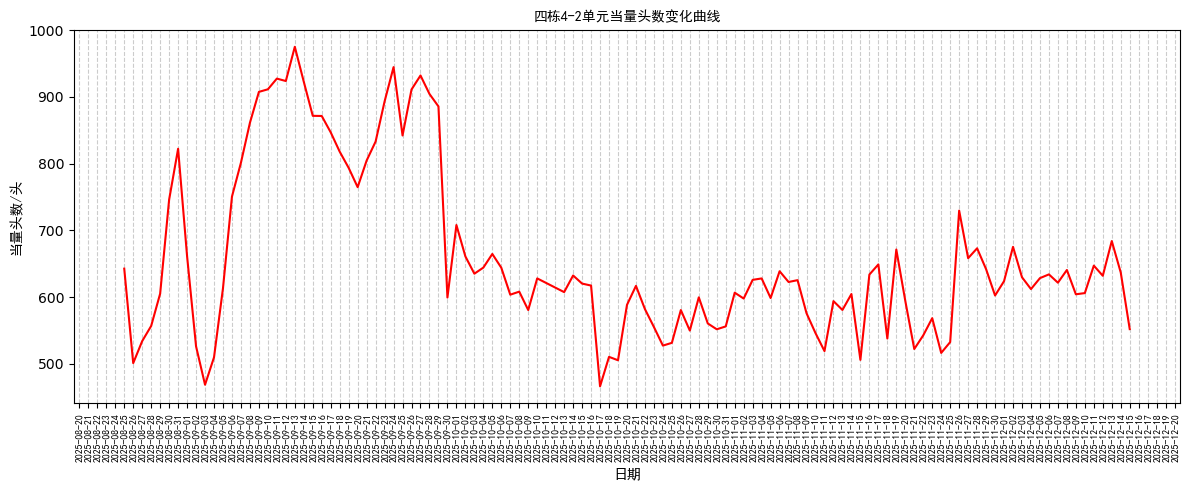

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 绘图参数配置
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(12, 5))
plt.plot(df_total.index, df_total['N_estimated'], color='red')
plt.xlabel('日期', fontproperties=CN_font)
plt.ylabel('当量头数/头', fontproperties=CN_font)
plt.title(f'四栋4-2单元当量头数变化曲线', fontproperties=CN_font)

# 图细节
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.4)  # 只显示 x 轴网格线

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)
plt.tight_layout()
plt.savefig(f'figure/四栋4-2单元当量头数变化曲线.png', dpi=300, bbox_inches='tight')
plt.show()

## 3 计算当前料肉比

In [ ]:
import pandas as pd

# 平均猪只的摄入料量（采用拟合曲线）/ 平均增重（减去保育初始20kg）
# 出栏数据
outlet_df = pd.read_excel('data/出栏数据.xlsx')[0:5]    # 一共出栏5天
total_n = outlet_df['屠宰厂接收头数'].sum()
total_weight_build = outlet_df['屠宰厂重量'].sum()  # kg

avg_weight = total_weight_build / total_n - 20

# 3栋总喂食数据(拟合)
intake_std_df = pd.read_excel('data/std_food_table_log_log_3.xlsx')
total_days = (pd.to_datetime('2025-12-30') - pd.to_datetime('2025-8-28')).days  # 数据周期长度

avg_intake = intake_std_df[(intake_std_df['age'] >= 32) & (intake_std_df['age'] <= 32 + total_days)]['food_e'].sum()       # 转舍日龄是32天

# 计算料肉比
fcr_curr = avg_intake / avg_weight
fcr_curr        # 当前料肉比约为 2.69

np.float64(2.6954267679028687)

In [ ]:
outlet_df

,日期,栋舍,出场头数,出场重量,出场均重,屠宰厂接收头数,总日龄,平均日龄,屠宰厂重量,平均体重,出场日增重,屠宰厂日增重,事故头数
0,2025-12-28 00:00:00,3栋,405,49203,121.49,403,62062,154.0,47811,118.64,936.55,913.18,2
1,2025-12-30 00:00:00,3栋,280,33136,118.34,280,42560,156.0,32174,114.91,896.07,868.36,0
2,2025-12-31 00:00:00,3栋,420,49190,117.12,417,63801,157.0,47848,114.74,879.11,860.11,3
3,2026-01-01 00:00:00,3栋,560,65837,117.57,560,91840,158.0,64648,115.44,875.68,858.83,0
4,2026-01-02 00:00:00,3栋,578,66492,115.04,577,96936,159.0,64666,112.07,848.88,825.53,1


In [ ]:
total_n

np.int64(2237)